In [58]:
import seaborn as sns
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [26]:
titanic = sns.load_dataset("titanic")

In [27]:
titanic_data = titanic.drop(columns = ["sibsp","parch","class","who","adult_male","deck","embark_town","alive","alone"])

In [28]:
titanic_data.isnull()
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   fare      891 non-null    float64
 5   embarked  889 non-null    object 
dtypes: float64(2), int64(2), object(2)
memory usage: 41.9+ KB


In [38]:
# Handling missing values
mean_imputer = SimpleImputer(strategy = "mean")
titanic_data[["age"]] = mean_imputer.fit_transform(titanic_data[["age"]])

mode_imputer = SimpleImputer(strategy = "most_frequent")
titanic_data[["embarked"]] = mode_imputer.fit_transform(titanic_data[["embarked"]])

In [41]:
# Encoding
le = LabelEncoder()
titanic_data["sex"] = le.fit_transform(titanic_data["sex"])
titanic_data["embarked"] = le.fit_transform(titanic_data["embarked"])

In [45]:
# Train test split
X = titanic_data.drop(columns = ["survived"])
y = titanic_data["survived"] 
 
X_train ,X_test , y_train, y_test = train_test_split(
    X , y, test_size = 0.2 , random_state = 42  
)

In [61]:
X_train.head()

,pclass,sex,age,fare,embarked
331,1,1,45.5,28.5000,2
733,2,1,23.0,13.0000,2
382,3,1,32.0,7.9250,2
704,3,1,26.0,7.8542,2
813,3,0,6.0,31.2750,2


In [53]:
model = DecisionTreeClassifier()
model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [55]:
y_pred = model.predict(X_test)
print(f"accuracy : {accuracy_score(y_test,y_pred)}")

accuracy : 0.770949720670391


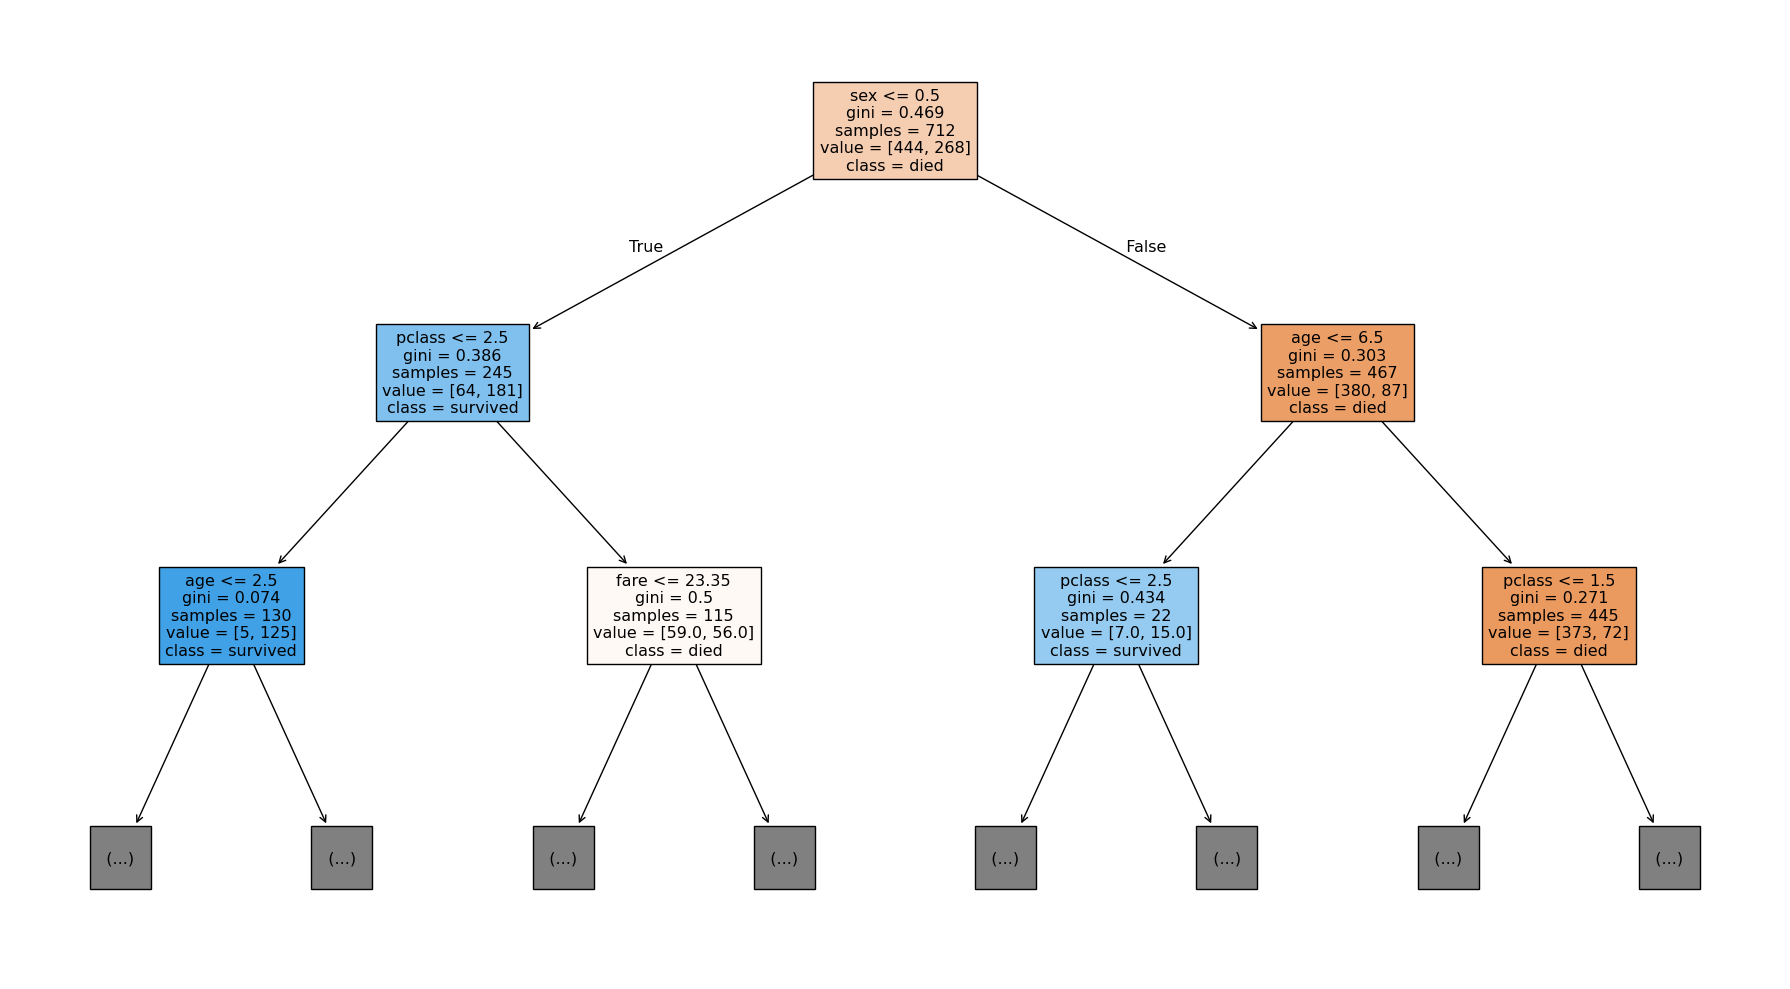

In [60]:
plt.figure(figsize = (18,10))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["died","survived"],
    filled = True, 
    max_depth = 2 
)
plt.tight_layout()
plt.show()

In [62]:
# Decision tree with prepruning 

# max depth
max_depth = [2,3,4,5,6,7,8,9,10]

for depth in max_depth:
    model = DecisionTreeClassifier(max_depth = depth)
    model.fit(X_train,y_train)
    accuracy = model.score(X_test,y_test)
    print(f"for depth : {depth} accuracy = {accuracy}")

for depth : 2 accuracy = 0.7653631284916201
for depth : 3 accuracy = 0.7988826815642458
for depth : 4 accuracy = 0.7988826815642458
for depth : 5 accuracy = 0.7988826815642458
for depth : 6 accuracy = 0.7988826815642458
for depth : 7 accuracy = 0.7988826815642458
for depth : 8 accuracy = 0.7877094972067039
for depth : 9 accuracy = 0.7988826815642458
for depth : 10 accuracy = 0.7821229050279329


In [65]:
# min samples split
min_samples = [2,3,5,10,15,20,25,30,35,40]
for samples in min_samples:
    model = DecisionTreeClassifier(max_depth = 3 , min_samples_split = samples)
    model.fit(X_train,y_train)
    accuracy = model.score(X_test,y_test)
    print(f"for samples : {samples} accuracy = {accuracy}")

for samples : 2 accuracy = 0.7988826815642458
for samples : 3 accuracy = 0.7988826815642458
for samples : 5 accuracy = 0.7988826815642458
for samples : 10 accuracy = 0.7988826815642458
for samples : 15 accuracy = 0.7988826815642458
for samples : 20 accuracy = 0.7988826815642458
for samples : 25 accuracy = 0.7932960893854749
for samples : 30 accuracy = 0.7932960893854749
for samples : 35 accuracy = 0.7932960893854749
for samples : 40 accuracy = 0.7932960893854749


In [66]:
# Post pruning 
full_tree = DecisionTreeClassifier(random_state = 42)
full_tree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [68]:
path = full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas = path.ccp_alphas

In [84]:
# Train model for each aplha and find the best apha value 

best_alpha = 0 
best_accuracy = 0 


for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state = 42,ccp_alpha=alpha)
    model.fit(X_train,y_train)
    accuracy = model.score(X_test,y_test)
    if best_accuracy < accuracy:
        best_accuracy = accuracy
        best_alpha = alpha

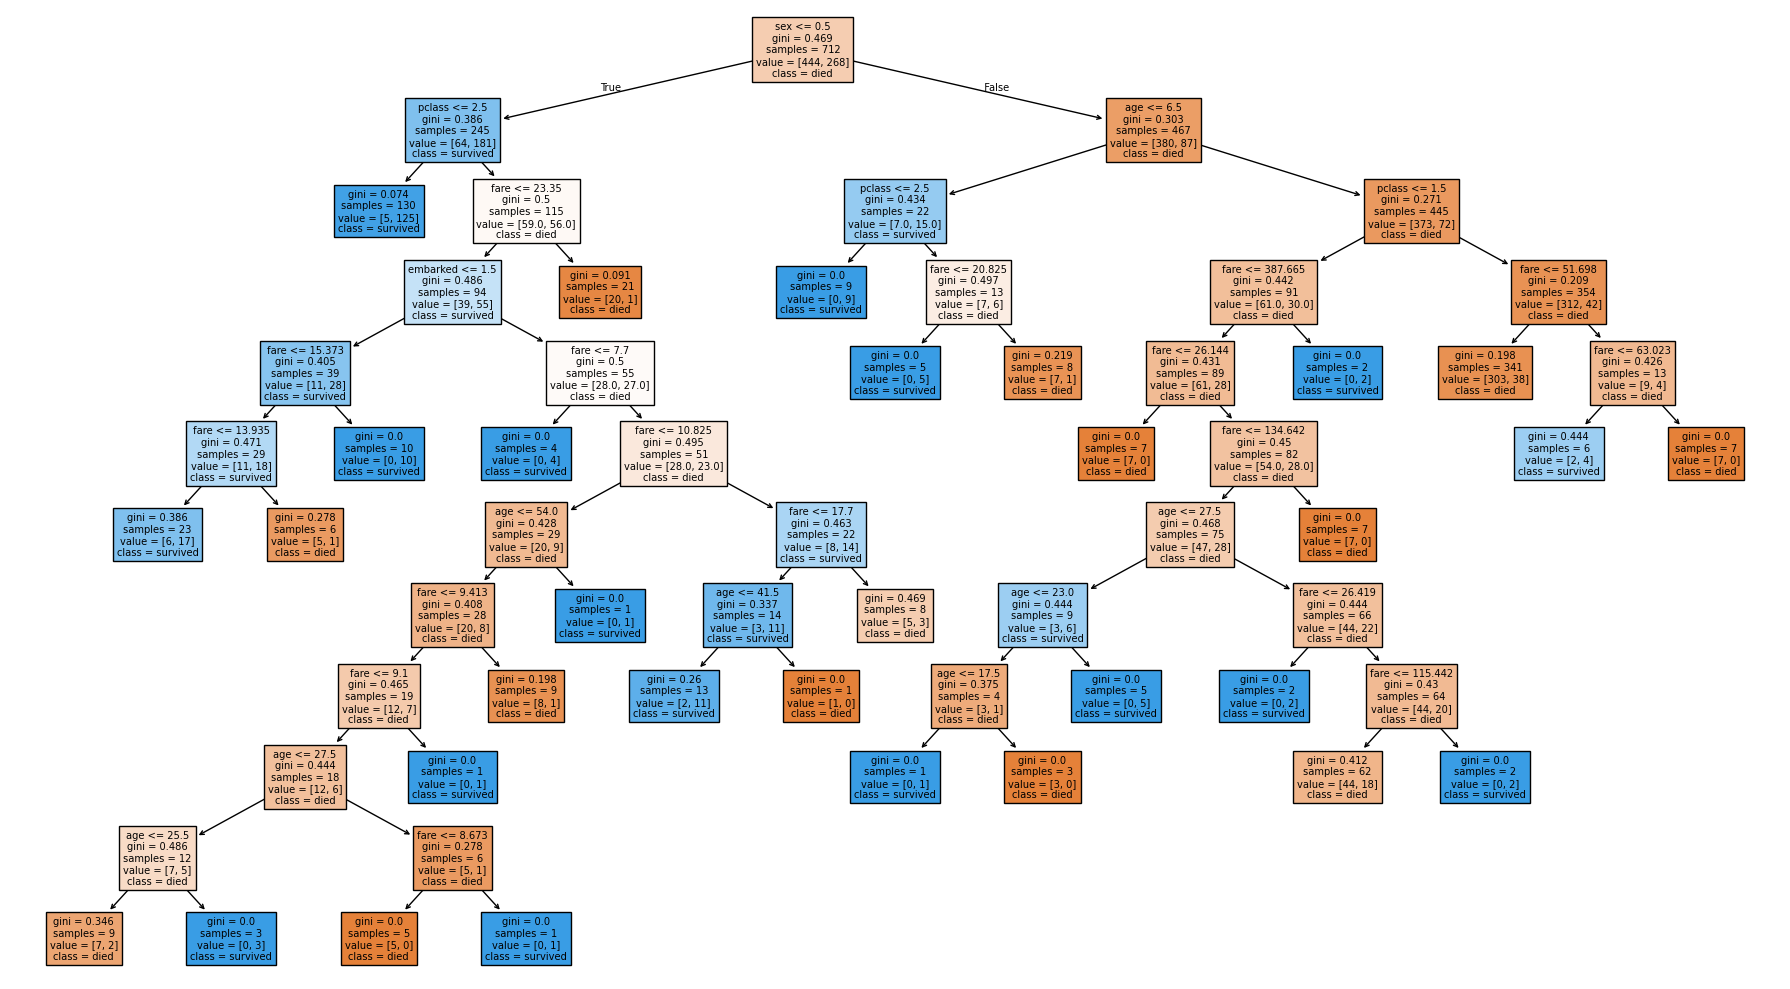

In [93]:
# best model 
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha)
best_model.fit(X_train,y_train)
accuracy = best_model.score(X_test,y_test)

plt.figure(figsize = (18,10))
plot_tree(
    best_model,
    feature_names = X.columns,
    class_names = ["died","survived"],
    filled = True
)
plt.tight_layout()
plt.show()